# PyDeriveHelper Introduction

`pyderivehelper` is a set of Python tools for performing mathematical calculations using Wolfram Language in a Jupyter notebook. Interfaces are provided for entering Wolfram Code directly and via natural language descriptions through OpenAI API calls.

The natural language interfaces abstract a series of processing pipelines which use OpenAI API calls to generate Wolfram Language code, validate the result, and render the result in the notebook. This paradigm saves token usage and minimizes errors by relying on OpenAI models for translation between natural language and code, while relying on the Wolfram Kernel for all computational tasks.

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

## Direct Wolfram Code Evaluation

The `wc` and `wplot` commands enable directly evaluating Wolfram Language code.

In [2]:
from pyderivehelper.wltools import (
    wc,
    wplot,
)


### `wc` Interface

The `wc` interface calls the Wolfram Engine and evaluates the input as Wolfram Language code directly. By default, results are saved as `rrr`.

Results can also be saved in a variable of choice.

The result after each call to `wc` is printed in TeX for convenience and readability.

In [3]:
wc('Sin[x]/Cos[x]')
wc('Series[rrr, {x, 0, 5}]')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

SeriesData[Global`x, 0, << 2 >>, 6, 1]

Calls to `wc` can also create user-defined variables, which can then be used in subsequent calls.

In [4]:
wc('MyResult = Sinh[x]/Cosh[x]')
wc('Series[MyResult, {x, 0, 5}]')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

SeriesData[Global`x, 0, << 2 >>, 6, 1]

#### Sanitization

Results from wc are sanitized to remove TeX paradigms that will not render correctly via MathJax within Jupyter.

In [5]:
# \fbox is not fully supported by MathJax, but is fixed automatically
wc('ConditionalExpression[x, x > 0]')

# hypergeometric functions are fixed automatically
wc('Integrate[Sin[x] ^ n, x]')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[-1, Cos[Global`x], << 1 >>, Power[Sin[Global`x], Plus[1, Global`n]], Power[Power[Sin[Global`x], 2], Times[Rational[1, 2], Plus[-1, Times[-1, Global`n]]]]]

### `wplot` Interface

The `wplot` wrapper can be used to quickly generate a plot and save the figure.

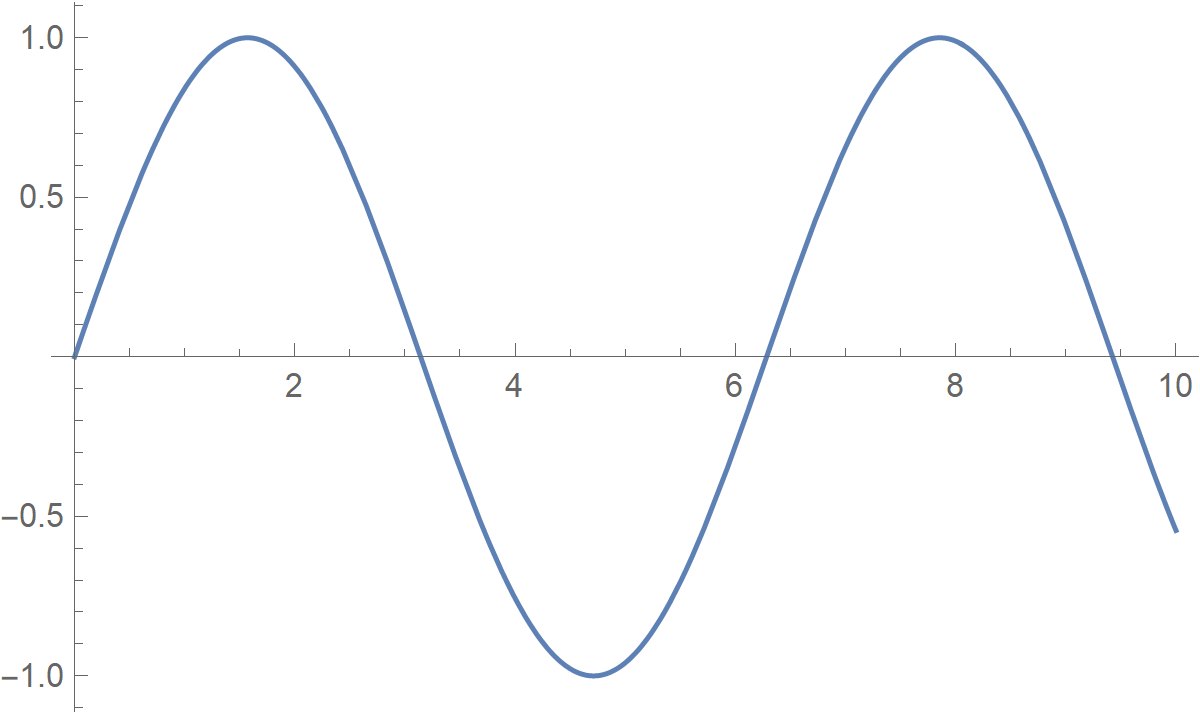

In [6]:
wplot('images/test.png', 'Plot[Sin[x], {x, 0, 10}]')

### `print_tex` and `print_wresult_tex`

Additional wrappers are provided for other basic tasks:
* `print_tex()` prints a raw TeX expression as MathJax in Jupyter
* `print_wresult_tex()` evaluates a Wolfram Language expression and prints the result in TeX (useful for copying results into drafts/documents).

In [7]:
from pyderivehelper.wltools import print_tex, print_wresult_tex

print_tex(r'\frac{d}{dx} \sin(x) = \cos(x)')
print_wresult_tex('Sin[x]/Cos[x] + Sinh[x]/Cosh[x]')

<IPython.core.display.Math object>

```tex
\tan (x)+\tanh (x)
```

## Natural Language Interfaces

Natural language interfaces provide the ability to describe a desired calculation in natural language and automatically convert the calculation to Wolfram Language for evaluation.

### `wnlc` Usage

Wolfram Natural Language Calculator (WNLC) is the main interface for performing calculations specified via natural language. 

In [8]:
from pyderivehelper.wltools import wnlc

The help message provides details on `wnlc` usage.

In [9]:
wnlc('/help')

## Wolfram Natural Language Calculator (WNLC) Interface Commands Help

WNLC provides an interface to use natural language to generate Wolfram Language code, evaluate it, and display the result in a Jupyter notebook.

Use commands of the form `/command` to choose what WNLC should return. If no command is provided, the default pipeline is used.

The following pipelines are provided:

- `Default (no command)` generates Wolfram Language code, runs it, and shows the code, result, and rendered math.
- `/code` generates Wolfram Language code but does not run it.
- `/tex` generates TeX but does not run anything.
- `/run` runs Wolfram Language code supplied directly.
- `/calc` generates and runs Wolfram Language code, then shows only the final rendered result.
- `/help` shows this message.

### Default Pipeline

Use the default pipeline to execute the full workflow from a plain-language prompt.

The default pipeline generates Wolfram Language code, checks it, shows the code, and then runs it. If the result is a plot, WNLC renders the plot image. Otherwise, it shows the raw result, the TeX form, and a rendered math view. If WNLC cannot repair invalid generated code, it shows the failed code instead of running it.

### `/code` Pipeline

Use `/code` to generate Wolfram Language code without running it.

When the `/code` command prefaces a prompt, WNLC turns the plain-language prompt into checked Wolfram Language code and displays the final code only. It does not evaluate the code or render plots. If the generated code cannot be repaired, WNLC shows the failed code instead.

### `/tex` Pipeline

Use `/tex` to generate TeX directly without converting to Wolfram Language or evaluating anything.

When the `/tex` command prefaces a prompt, WNLC turns a plain-language prompt into checked TeX and displays the final TeX only. It does not generate runnable Wolfram output or evaluate anything. If the generated TeX cannot be repaired, WNLC shows the failed TeX instead.

### `/run` Pipeline

Use `/run` for Wolfram Language code that should be checked and run.

When the `/run` command prefaces a prompt, WNLC validates supplied code, attempts simple repairs if needed, shows the final code, and then evaluates it. It displays the raw result, the TeX form, and a rendered math view. If the code cannot be repaired, WNLC shows the failed code instead of running it.

### `/calc` Pipeline

Use `/calc` for a compact answer from a plain-language prompt.

When the `/calc` command prefaces a prompt, WNLC generates and checks Wolfram Language code, then runs it. For ordinary results, it shows only the final rendered math. If the result is a plot, WNLC renders the plot image instead. If the generated code cannot be repaired, WNLC shows the failed code instead of running it.

### `/help` Pipeline

Use `/help` to display this help message.


#### `wnlc` Default Pipeline Examples

The following examples show use of the `wnlc` default pipeline.

In [10]:
wnlc('Take the derivative of sin(x) with respect to x.')


**Generated Wolfram Code**:


```wolfram
FullSimplify[D[Sin[x], x]]
```


**Raw Evaluated Result**:


```plaintext
Cos[Global`x]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large \cos (x)$$

---

(Cos[Global`x], '\\cos (x)')

In [11]:
wnlc('Take the Taylor series of sin(x) at x=0 to 10 terms.')


**Generated Wolfram Code**:


```wolfram
FullSimplify[Series[Sin[x], {x, 0, 9}]]
```


**Raw Evaluated Result**:


```plaintext
SeriesData[Global`x, 0, << 2 >>, 10, 1]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large x-\frac{x^3}{6}+\frac{x^5}{120}-\frac{x^7}{5040}+\frac{x^9}{362880}+O\left(x^{10}\right)$$

---

(SeriesData[Global`x, 0, << 2 >>, 10, 1],
 'x-\\frac{x^3}{6}+\\frac{x^5}{120}-\\frac{x^7}{5040}+\\frac{x^9}{362880}+O\\left(x^{10}\\right)')

The Wolfram Integration engine is powerful, and recognizes closed forms of many difficult integrals in terms of generalized special functions.

In [12]:
wnlc('Integrate sin^n(x) with respect to x.')


**Generated Wolfram Code**:


```wolfram
FullSimplify[Integrate[Sin[x]^n, x]]
```


**Raw Evaluated Result**:


```plaintext
Times[-1, Cos[Global`x], << 1 >>, Power[Sin[Global`x], Plus[1, Global`n]], Power[Power[Sin[Global`x], 2], Plus[Rational[-1, 2], Times[Rational[-1, 2], Global`n]]]]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large -\cos (x) \sin ^{n+1}(x) \sin ^2(x)^{-\frac{n}{2}-\frac{1}{2}} \, {}_2F_1\left(\frac{1}{2},\frac{1-n}{2};\frac{3}{2};\cos ^2(x)\right)$$

---

(Times[-1, Cos[Global`x], << 1 >>, Power[Sin[Global`x], Plus[1, Global`n]], Power[Power[Sin[Global`x], 2], Plus[Rational[-1, 2], Times[Rational[-1, 2], Global`n]]]],
 '-\\cos (x) \\sin ^{n+1}(x) \\sin ^2(x)^{-\\frac{n}{2}-\\frac{1}{2}} \\, {}_2F_1\\left(\\frac{1}{2},\\frac{1-n}{2};\\frac{3}{2};\\cos ^2(x)\\right)')

In [13]:
wnlc('Integrate e^(-2x) * ln(x) * x^2 with respect to x.')


**Generated Wolfram Code**:


```wolfram
FullSimplify[Integrate[Exp[-2 x] Log[x] x^2, x]]
```


**Raw Evaluated Result**:


```plaintext
Times[Rational[1, 8], Power[E, Times[-2, Global`x]], Plus[-3, Times[-2, Global`x], Times[2, Power[E, Times[2, Global`x]], ExpIntegralEi[Times[-2, Global`x]]], Times[-2, Plus[1, Times[2, Global`x, Plus[1, Global`x]]], Log[Global`x]]]]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large \frac{1}{8} e^{-2 x} \left(2 e^{2 x} \text{Ei}(-2 x)-2 x-2 (2 x (x+1)+1) \log (x)-3\right)$$

---

(Times[Rational[1, 8], Power[E, Times[-2, Global`x]], Plus[-3, Times[-2, Global`x], Times[2, Power[E, Times[2, Global`x]], ExpIntegralEi[Times[-2, Global`x]]], Times[-2, Plus[1, Times[2, Global`x, Plus[1, Global`x]]], Log[Global`x]]]],
 '\\frac{1}{8} e^{-2 x} \\left(2 e^{2 x} \\text{Ei}(-2 x)-2 x-2 (2 x (x+1)+1) \\log (x)-3\\right)')

In [14]:
wnlc(
    'Substitute u = x^2 into the expression sin(u) and integrate with respect to x.'
)


**Generated Wolfram Code**:


```wolfram
FullSimplify[Integrate[Sin[x^2], x]]
```


**Raw Evaluated Result**:


```plaintext
Times[Power[Times[Rational[1, 2], Pi], Rational[1, 2]], FresnelS[Times[Power[Times[2, Power[Pi, -1]], Rational[1, 2]], Global`x]]]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large \sqrt{\frac{\pi }{2}} S\left(\sqrt{\frac{2}{\pi }} x\right)$$

---

(Times[Power[Times[Rational[1, 2], Pi], Rational[1, 2]], FresnelS[Times[Power[Times[2, Power[Pi, -1]], Rational[1, 2]], Global`x]]],
 '\\sqrt{\\frac{\\pi }{2}} S\\left(\\sqrt{\\frac{2}{\\pi }} x\\right)')

In [15]:
wnlc('Integrate x^2 + y^2, then integrate the result with respect to y')


**Generated Wolfram Code**:


```wolfram
FullSimplify[Integrate[Integrate[Evaluate@ (x^2 + y^2), x], y]]
```


**Raw Evaluated Result**:


```plaintext
Times[Rational[1, 3], Global`x, Global`y, Plus[Power[Global`x, 2], Power[Global`y, 2]]]
```


**Raw TeX**:


...

---


**Rendered Evaluated Result**:


$$\Large \frac{1}{3} x y \left(x^2+y^2\right)$$

---

(Times[Rational[1, 3], Global`x, Global`y, Plus[Power[Global`x, 2], Power[Global`y, 2]]],
 '\\frac{1}{3} x y \\left(x^2+y^2\\right)')

WNLC will automatically detect if the user is asking for a plot, and will generate the plot, render it in the notebook, and save the plot as an image. The save location is defined in `config.yaml`.


**Generated Wolfram Code**:


```wolfram
Plot[{Evaluate@Sin[x], Evaluate@Normal@Series[Sin[x], {x, 0, 5}]}, {x, -5, 5}, PlotStyle -> {Directive[Black, Thick], Directive[Black, Dashed, Thick]}, PlotLegends -> None]
```

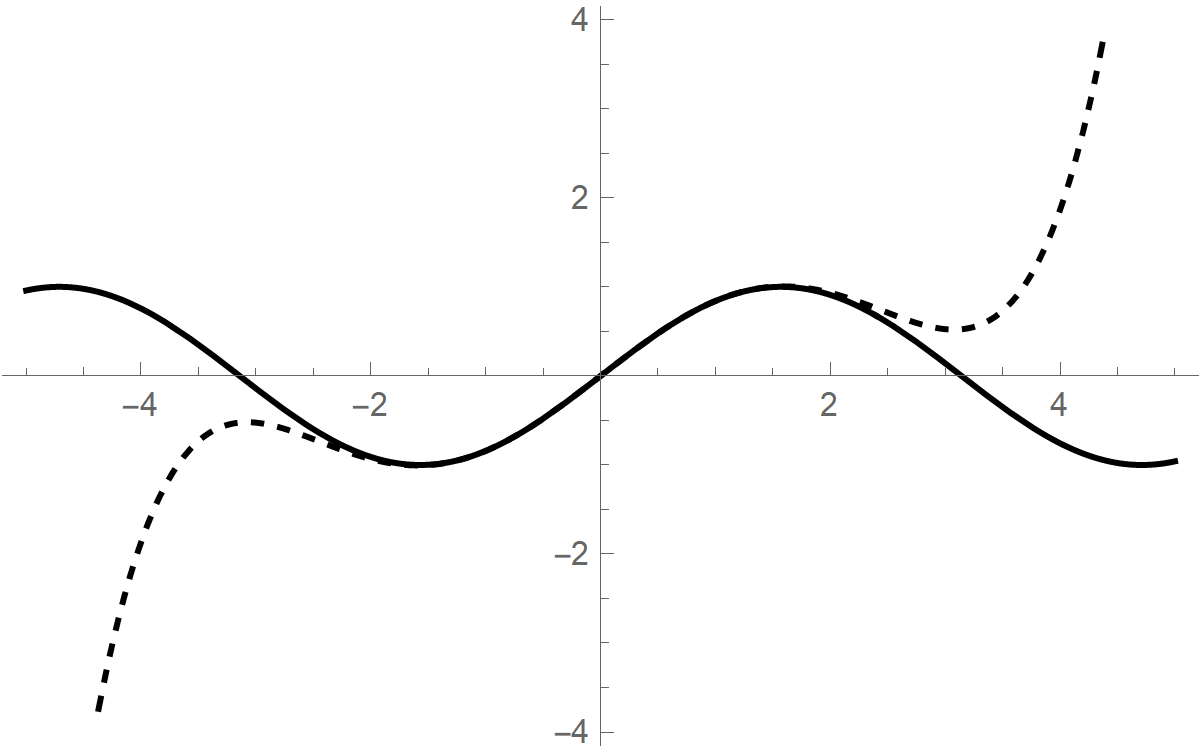

In [16]:
wnlc("""
Plot the function sin(x) and its 5th-order Taylor series approximation on the same graph for x in the range [-5, 5].
Make the plot black and white, and use different line styles for the two functions.
Do not include a legend.
""")


**Generated Wolfram Code**:


```wolfram
ComplexPlot[Evaluate@Tanh[z], {z, -5 - 5 I, 5 + 5 I}]
```

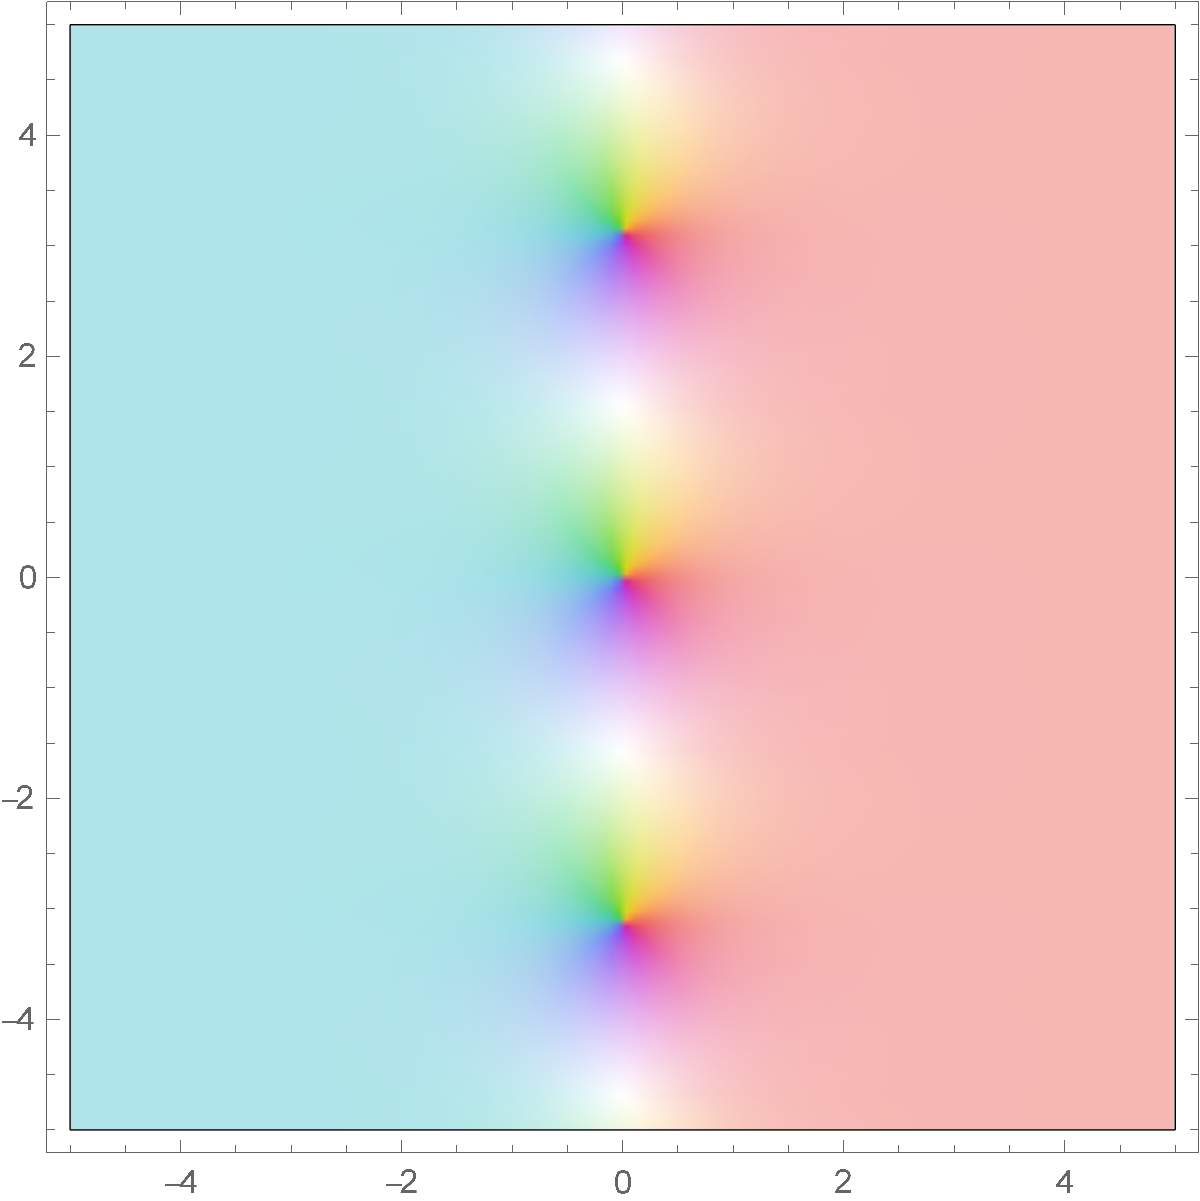

In [17]:
wnlc('Generate a complex plot of tanh(x) from -5-5I to 5+5I.')

#### `wnlc` Slash Command Examples

The `wnlc` slash commands provide control over which pipeline steps are executed. Slash commands are expected at the beginning of the prompt (ignoring leading space). Each command defines a pipeline. If multiple commands are present, the pipeline runs multiple times.

In [18]:
wnlc('   /code /tex /run /calc d/dx cos(x)')


**Generated Wolfram Code**:


```wolfram
FullSimplify[D[Cos[x], x]]
```


**Generated TeX**:


```tex
\frac{d}{dx}\cos(x)
```


**Generated Wolfram Code**:


...

---


**Rendered Evaluated Result**:


$$\Large -\sin (x)$$

---

$$\Large -\sin (x)$$

Note that slash commands after an invalid command will be ignored.

In [19]:
wnlc('/code /invalid /calc d/dz e^(c*z)')

ERROR:pyderivehelper.wltools:Unknown slash command /invalid. Any subsequent slash commands were ignored.



**Generated Wolfram Code**:


```wolfram
FullSimplify[D[Exp[c z], z]]
```

Use `/code` to generate Wolfram Language code without evaluating it.

In [20]:
wnlc(' /code d/dy y^3')
wnlc('/code sin(2pi) + cos(2pi) + tan(2pi)')


**Generated Wolfram Code**:


```wolfram
FullSimplify[D[y^3, y]]
```


**Generated Wolfram Code**:


```wolfram
FullSimplify[Sin[2 Pi] + Cos[2 Pi] + Tan[2 Pi]]
```

Use `/tex` to generate TeX and do nothing else.

In [21]:
wnlc('/tex sum from n= 1 to infinity of 1/n^2')


**Generated TeX**:


```tex
\sum_{n=1}^{\infty}\frac{1}{n^2}
```

Use `/run` to run Wolfram Code. The `/run` pipeline works like `wc` but will attempt to fix the user code before running.

In [22]:
wnlc('/run Simplify Cos(x)/Sin(x)')


**Generated Wolfram Code**:


```wolfram
FullSimplify[Simplify[Cos[x]/Sin[x]]]
```


**Raw Evaluated Result**:


```plaintext
Cot[Global`x]
```


**Raw TeX**:


```tex
\cot (x)
```

---


**Rendered Evaluated Result**:


$$\Large \cot (x)$$

---

Use `/calc` to calculate and print the result with no additional output.

In [23]:
wnlc('/calc d/dx (x^2 * sin(x))')
wnlc('/calc integral sin(x)*e^(-x) dx')

$$\Large x (2 \sin (x)+x \cos (x))$$

$$\Large -\frac{1}{2} e^{-x} (\sin (x)+\cos (x))$$

## Additional Functionality

Additional functionalities, such as configuration settings and logging, are covered here.

### Setting the logger level

The logger level defaults to `WARNING` (only log warnings or more severe messages). The logger level can be changed with `set_log_level`

In [24]:
from pyderivehelper.wltools import set_log_level

set_log_level('DEBUG')

wnlc('Compute the derivative of sin(x)')

INFO:pyderivehelper.wltools:Logger level: DEBUG
INFO:pyderivehelper.wltools:Executing default pipeline...
INFO:pyderivehelper.wltools:Generating Wolfram Language code...
INFO:pyderivehelper.wltools:Sanitizing generated code...
INFO:pyderivehelper.wltools:Validating code...



**Generated Wolfram Code**:


```wolfram
FullSimplify[D[Sin[x], x]]
```

INFO:pyderivehelper.wltools:Checking for plot code...
INFO:pyderivehelper.wltools:Evaluating code...



**Raw Evaluated Result**:


...

---


**Rendered Evaluated Result**:


$$\Large \cos (x)$$

---

(Cos[Global`x], '\\cos (x)')

### Configuration File Parameters

Additional configurability is provided in the `config.yaml` file.

The following fields are provided:

* `openai_api_key_env_var`: Name of the environment variable that stores the user's OpenAI API key for this project.
* `plot_directory`: Directory to store plots in.
* `plot_extension`: Type of plot extension to use (e.g., .png)
* `result_str`: Variable to store Wolfram results in (defaults to `rrr`)
* `wolfram_code_validation_retry_count`: Maximum number of attempts to fix code that fails validation before returning an error and reporting unfixable code.

The system prompts and template prompts for each pipeline task are also exposed for advanced users to edit.
